In [1]:
! pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 49.6 MB/s eta 0:00:00


In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.DataStructs import TanimotoSimilarity
from rdkit.Chem.Scaffolds import MurckoScaffold
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from rdkit.Chem import Descriptors
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from rdkit.Chem import Draw

In [3]:
compounds_egfr = {
    #plant_compounds
    "Withaferin A": "CC1=C(C(=O)O[C@H](C1)[C@@H](C)[C@H]2CC[C@@H]3[C@@]2(CC[C@H]4[C@H]3C[C@@H]5[C@]6([C@@]4(C(=O)C=C[C@@H]6O)C)O5)C)CO",
    "Camptothecin_Plant": "CC[C@@]1(C2=C(COC1=O)C(=O)N3CC4=CC5=CC=CC=C5N=C4C3=C2)O",
    "Hesperidin": "C[C@H]1[C@@H]([C@H]([C@H]([C@@H](O1)OC[C@@H]2[C@H]([C@@H]([C@H]([C@@H](O2)OC3=CC(=C4C(=O)C[C@H](OC4=C3)C5=CC(=C(C=C5)OC)O)O)O)O)O)O)O)O",
    "Withanolide A": "CC1=C(C(=O)O[C@H](C1)[C@@](C)([C@H]2CC[C@@H]3[C@@]2(CC[C@H]4[C@H]3[C@H]5[C@H](O5)[C@@]6([C@@]4(C(=O)C=CC6)C)O)C)O)C",

    #endophyte_compounds
    "Camptothecin_Endophyte": "CC[C@@]1(C2=C(COC1=O)C(=O)N3CC4=CC5=CC=CC=C5N=C4C3=C2)O",
    "Aspochalasin M": "C[C@H]1[C@H]2[C@@H](NC(=O)[C@@]23[C@@H](/C=C(\\CCC(=O)[C@H](CCC3=O)O)/C)C=C1C)CC(C)C",
    "Emodin": "CC1=CC2=C(C(=C1)O)C(=O)C3=C(C2=O)C=C(C=C3O)O",
    "Quercetin": "C1=CC(=C(C=C1C2=C(C(=O)C3=C(C=C(C=C3O2)O)O)O)O)O"

}

In [4]:
fps = {}

for name, smile in compounds_egfr.items():
    mol = Chem.MolFromSmiles(smile)
    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=2,
        nBits=2048
    )
    fps[name] = fp

[22:45:24] DEPRECATION WARNING: please use MorganGenerator
[22:45:24] DEPRECATION WARNING: please use MorganGenerator
[22:45:24] DEPRECATION WARNING: please use MorganGenerator
[22:45:24] DEPRECATION WARNING: please use MorganGenerator
[22:45:24] DEPRECATION WARNING: please use MorganGenerator
[22:45:24] DEPRECATION WARNING: please use MorganGenerator
[22:45:24] DEPRECATION WARNING: please use MorganGenerator
[22:45:24] DEPRECATION WARNING: please use MorganGenerator


In [5]:
names= list(compounds_egfr.keys())

similarity_matrix = []

for i in names:
    row = []

    for j in names:
        sim = TanimotoSimilarity(
            fps[i],
            fps[j]
        )
        row.append(round(sim, 2))

    similarity_matrix.append(row)

df = pd.DataFrame(
    similarity_matrix,
    index=names,
    columns=names
)

df

,Withaferin A,Camptothecin_Plant,Hesperidin,Withanolide A,Camptothecin_Endophyte,Aspochalasin M,Emodin,Quercetin
Withaferin A,1.00,0.13,0.11,0.27,0.13,0.15,0.08,0.06
Camptothecin_Plant,0.13,1.00,0.12,0.16,1.00,0.12,0.10,0.10
Hesperidin,0.11,0.12,1.00,0.11,0.12,0.11,0.15,0.14
Withanolide A,0.27,0.16,0.11,1.00,0.16,0.12,0.09,0.07
Camptothecin_Endophyte,0.13,1.00,0.12,0.16,1.00,0.12,0.10,0.10
Aspochalasin M,0.15,0.12,0.11,0.12,0.12,1.00,0.10,0.06
Emodin,0.08,0.10,0.15,0.09,0.10,0.10,1.00,0.22
Quercetin,0.06,0.10,0.14,0.07,0.10,0.06,0.22,1.00


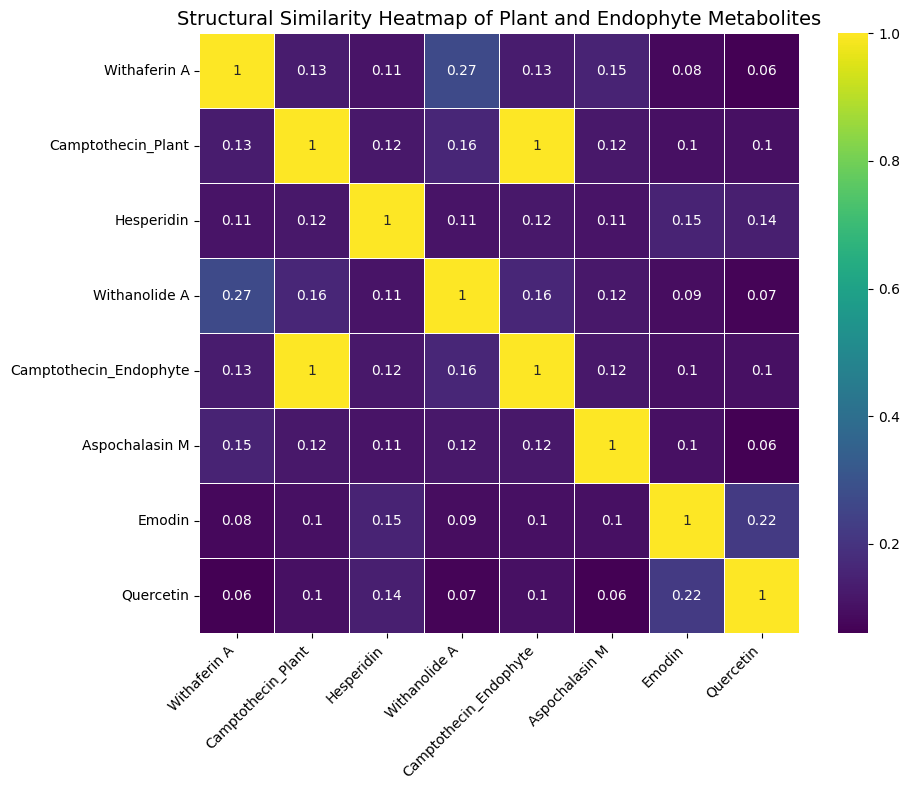

In [6]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df,
    annot=True,
    cmap="viridis",
    linewidths=0.5,
    square=True
)

plt.title(
    "Structural Similarity Heatmap of Plant and Endophyte Metabolites",
    fontsize=14
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "structural_similarity_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [7]:
# EGFR
plant_egfr = [-9.9, -9.9, -9.8, -9.5]
endo_egfr = [-9.9, -9.6, -9.0, -8.9]


print("\nEGFR")
print("Plant Mean:", np.mean(plant_egfr))
print("Endophyte Mean:", np.mean(endo_egfr))

t_stat, p_val = ttest_ind(plant_egfr, endo_egfr)

print("P-value:", p_val)


EGFR
Plant Mean: -9.775
Endophyte Mean: -9.35
P-value: 0.15032619384503965


In [8]:
descriptor_list = []

for name, smile in compounds_egfr.items():
    mol = Chem.MolFromSmiles(smile)

    descriptor_list.append([
        name,
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.TPSA(mol)
    ])

desc_df = pd.DataFrame(
    descriptor_list,
    columns=["Compound","MW","LogP","HDonors","HAcceptors","TPSA"]
)

In [9]:
features = desc_df.iloc[:,1:]
scaled = StandardScaler().fit_transform(features)

In [10]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled)

desc_df['PC1'] = pca_result[:,0]
desc_df['PC2'] = pca_result[:,1]

In [11]:
desc_df["Category"] = [
    "Plant","Plant","Plant","Plant",
    "Endophyte","Endophyte","Endophyte","Endophyte"
]

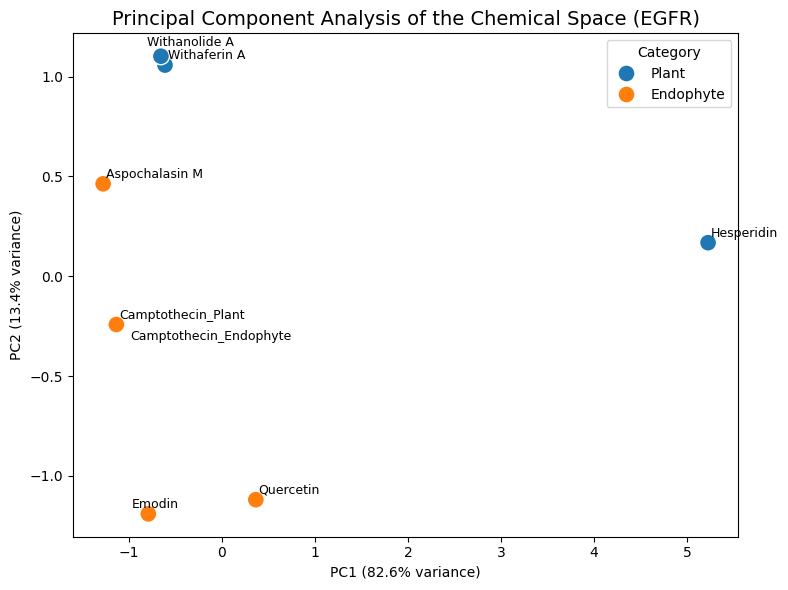

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Category',
    data=desc_df,
    s=150
)

for i, row in desc_df.iterrows():

    x = row["PC1"]
    y = row["PC2"]

    if row["Compound"] == "Camptothecin_Endophyte":
        plt.text(x + 0.15, y - 0.08, row["Compound"], fontsize=9)

    elif row["Compound"] == "Emodin":
        plt.text(x - 0.18, y + 0.03, row["Compound"], fontsize=9)

    elif row["Compound"] == "Withanolide A":
        plt.text(x - 0.15, y + 0.05, row["Compound"], fontsize=9)

    else:
        plt.text(x + 0.03, y + 0.03, row["Compound"], fontsize=9)

plt.title(
    "Principal Component Analysis of the Chemical Space (EGFR)",
    fontsize=14
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")

plt.tight_layout()

plt.savefig(
    "PCA_chemical_space.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()